In [33]:
#Library importation

%matplotlib inline
import torch
from torch import nn
import os
from google.colab import drive
import pandas as pd
import torch
from sklearn.model_selection import train_test_split
from torch.utils.data import TensorDataset, DataLoader
import re
import random
from transformers import BertTokenizer, BertModel
import matplotlib.pyplot as plt
!pip install bitsandbytes
import bitsandbytes as bnb
from torch.optim import AdamW

In [2]:
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import torch

gpu_stats = torch.cuda.get_device_properties(0)

print(f"GPU = {gpu_stats.name}.")

# A key attribute is the amount of memory, in GB, the GPU has
gpu_memory = round(gpu_stats.total_memory / 1024 / 1024 / 1024, 3)

print(f"GPU Memory = {gpu_memory} GB")

# Storing a shorthand version of the gpu
if "T4" in gpu_stats.name:
    gpu = "T4"

elif "L4" in gpu_stats.name:
    gpu = "L4"

elif "A100" in gpu_stats.name:
    gpu = "A100"

else:
    raise ValueError(f"Unsupported GPU: {gpu_stats.name}")

print("Shorthand Name:", gpu_stats.name, ' -->', gpu )

GPU = Tesla T4.
GPU Memory = 14.563 GB
Shorthand Name: Tesla T4  --> T4


In [4]:
df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/train.csv", skiprows=5)  # skip first 5 rows
#/content/sample_data/train.csv

In [5]:
df

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,30192,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1.0,0.0,0.0
1,53567,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0.0,1.0,0.0
2,65089,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0.0,0.0,1.0
3,96401,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1.0,0.0,0.0
4,198779,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...
29996,2231479603,zephyr-7b-beta,mistral-7b-instruct,"[""What is the best book to learn core linux te...","[""\""Linux Command Line and Shell Scripting Bib...","[""There are many books available that can help...",0.0,0.0,1.0
29997,2231629757,gpt-3.5-turbo-0613,claude-1,"[""How to make a drink""]","[""To make a drink, you'll need to follow a few...","[""Here are the basic steps to make a drink:\n\...",1.0,0.0,0.0
29998,2231793501,claude-2.0,claude-1,"[""Describe what the fediverse is""]","[""The fediverse refers to a group of interconn...","[""The fediverse is a network of interconnected...",0.0,1.0,0.0
29999,2231800101,llama-2-13b-chat,claude-instant-1,"[""if the access size is 4096 and physical bloc...","[""If the access size is 4096 and the physical ...","[""Okay, let's break this down step-by-step:\n\...",0.0,0.0,1.0


In [6]:
df.tail(5)

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
29996,2231479603,zephyr-7b-beta,mistral-7b-instruct,"[""What is the best book to learn core linux te...","[""\""Linux Command Line and Shell Scripting Bib...","[""There are many books available that can help...",0.0,0.0,1.0
29997,2231629757,gpt-3.5-turbo-0613,claude-1,"[""How to make a drink""]","[""To make a drink, you'll need to follow a few...","[""Here are the basic steps to make a drink:\n\...",1.0,0.0,0.0
29998,2231793501,claude-2.0,claude-1,"[""Describe what the fediverse is""]","[""The fediverse refers to a group of interconn...","[""The fediverse is a network of interconnected...",0.0,1.0,0.0
29999,2231800101,llama-2-13b-chat,claude-instant-1,"[""if the access size is 4096 and physical bloc...","[""If the access size is 4096 and the physical ...","[""Okay, let's break this down step-by-step:\n\...",0.0,0.0,1.0
30000,>>>>>>> 7eec3817bac4f89adbcd615707cdc37a19e320fb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
df.info()
#This tells us the number of rows that have Nans values and other descriptive properties of the dataset
#In this case only one row has missing values

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30001 entries, 0 to 30000
Data columns (total 9 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   id              30001 non-null  object 
 1   model_a         30000 non-null  object 
 2   model_b         30000 non-null  object 
 3   prompt          30000 non-null  object 
 4   response_a      30000 non-null  object 
 5   response_b      30000 non-null  object 
 6   winner_model_a  30000 non-null  float64
 7   winner_model_b  30000 non-null  float64
 8   winner_tie      30000 non-null  float64
dtypes: float64(3), object(6)
memory usage: 2.1+ MB


In [8]:
# Finding that row/rows with missing values
df[df.isnull().any(axis=1)]

,id,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
30000,>>>>>>> 7eec3817bac4f89adbcd615707cdc37a19e320fb,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [9]:
df = df.dropna() # Removing that NaN row
df = df.drop(columns=['id']) # Removing the id column because it is not useful for intended purposes
df = df.iloc[0:15000]
df

,model_a,model_b,prompt,response_a,response_b,winner_model_a,winner_model_b,winner_tie
0,gpt-4-1106-preview,gpt-4-0613,"[""Is it morally right to try to have a certain...","[""The question of whether it is morally right ...","[""As an AI, I don't have personal beliefs or o...",1.0,0.0,0.0
1,koala-13b,gpt-4-0613,"[""What is the difference between marriage lice...","[""A marriage license is a legal document that ...","[""A marriage license and a marriage certificat...",0.0,1.0,0.0
2,gpt-3.5-turbo-0613,mistral-medium,"[""explain function calling. how would you call...","[""Function calling is the process of invoking ...","[""Function calling is the process of invoking ...",0.0,0.0,1.0
3,llama-2-13b-chat,mistral-7b-instruct,"[""How can I create a test set for a very rare ...","[""Creating a test set for a very rare category...","[""When building a classifier for a very rare c...",1.0,0.0,0.0
4,koala-13b,gpt-3.5-turbo-0314,"[""What is the best way to travel from Tel-Aviv...","[""The best way to travel from Tel Aviv to Jeru...","[""The best way to travel from Tel-Aviv to Jeru...",0.0,1.0,0.0
...,...,...,...,...,...,...,...,...
14995,vicuna-33b,gpt-3.5-turbo-0613,"[""* Reply 2 if the caller implicitly or explic...","[""2""]","[""0""]",0.0,1.0,0.0
14996,llama-2-70b-chat,gpt-4-0613,"[""Complete the setence: China is to Osaka like...","[""China is to Osaka like Portugal is to Macau....","[""Lisbon""]",0.0,0.0,1.0
14997,claude-instant-1,vicuna-33b,"[""You will be given an email and a question. Y...","[""This email does not contain useful informati...","[""The email contains useful information to ans...",0.0,1.0,0.0
14998,gpt-3.5-turbo-0125,gpt-4-0613,"[""List word combinations that rhyme with orange""]","[""I'm sorry, but there are very few words that...","[""1. Door Hinge\n2. Foreign\n3. Storage\n4. Po...",0.0,1.0,0.0


In [10]:
df.head

<bound method NDFrame.head of                        model_a              model_b  \
0           gpt-4-1106-preview           gpt-4-0613   
1                    koala-13b           gpt-4-0613   
2           gpt-3.5-turbo-0613       mistral-medium   
3             llama-2-13b-chat  mistral-7b-instruct   
4                    koala-13b   gpt-3.5-turbo-0314   
...                        ...                  ...   
14995               vicuna-33b   gpt-3.5-turbo-0613   
14996         llama-2-70b-chat           gpt-4-0613   
14997         claude-instant-1           vicuna-33b   
14998       gpt-3.5-turbo-0125           gpt-4-0613   
14999  llama2-70b-steerlm-chat     claude-instant-1   

                                                  prompt  \
0      ["Is it morally right to try to have a certain...   
1      ["What is the difference between marriage lice...   
2      ["explain function calling. how would you call...   
3      ["How can I create a test set for a very rare ...   
4      ["What is the best way to travel from Tel-Aviv...   
...                                                  ...   
14995  ["* Reply 2 if the caller implicitly or explic...   
14996  ["Complete the setence: China is to Osaka like...   
14997  ["You will be given an email and a question. Y...   
14998  ["List word combinations that rhyme with orange"]   
14999       ["Does Cartman from South Park hate poors?"]   

                                              response_a  \
0      ["The question of whether it is morally right ...   
1      ["A marriage license is a legal document that ...   
2      ["Function calling is the process of invoking ...   
3      ["Creating a test set for a very rare category...   
4      ["The best way to travel from Tel Aviv to Jeru...   
...                                                  ...   
14995                                              ["2"]   
14996  ["China is to Osaka like Portugal is to Macau....   
14997  ["This email does not contain useful informati...   
14998  ["I'm sorry, but there are very few words that...   
14999  ["In the animated television series South Park...   

                                              response_b  winner_model_a  \
0      ["As an AI, I don't have personal beliefs or o...             1.0   
1      ["A marriage license and a marriage certificat...             0.0   
2      ["Function calling is the process of invoking ...             0.0   
3      ["When building a classifier for a very rare c...             1.0   
4      ["The best way to travel from Tel-Aviv to Jeru...             0.0   
...                                                  ...             ...   
14995                                              ["0"]             0.0   
14996                                         ["Lisbon"]             0.0   
14997  ["The email contains useful information to ans...             0.0   
14998  ["1. Door Hinge\n2. Foreign\n3. Storage\n4. Po...             0.0   
14999  ["I don't have a definite view on Cartman's at...             1.0   

       winner_model_b  winner_tie  
0                 0.0         0.0  
1                 1.0         0.0  
2                 0.0         1.0  
3                 0.0         0.0  
4                 1.0         0.0  
...               ...         ...  
14995             1.0         0.0  
14996             0.0         1.0  
14997             1.0         0.0  
14998             1.0         0.0  
14999             0.0         0.0  

[15000 rows x 8 columns]>

# **Embedding Text**

In [11]:
# Set a random seed for reproducability each time
random_seed = 42
random.seed(random_seed)

# Set a random seed for PyTorch (for GPU as well)
torch.manual_seed(random_seed)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(random_seed)

In [12]:
# Loading BERT tokenizer and model
# This is the uncased model which means every upper cased is turned into lower case this for simplicity purposes
tokenizer = BertTokenizer.from_pretrained('bert-base-uncased')
model = BertModel.from_pretrained('bert-base-uncased')

# # Use smaller model than BERT base
# from transformers import AutoTokenizer, AutoModel
# tokenizer = AutoTokenizer.from_pretrained('prajjwal1/bert-tiny')  # much smaller!
# model = AutoModel.from_pretrained('prajjwal1/bert-tiny')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [13]:
# Tokenizing and encoding text using batch_encode_plus
# This function returns a dictionary containing the token IDs and attention masks

# encoding = tokenizer( df['prompt'].tolist(),# List of input texts, this passes all texts at once
#     # padding=True,
#     padding = 'longest',              # Pad to the maximum sequence length
#     truncation= True,           # Truncate to the maximum sequence length if necessary

#     return_tensors='pt',      # Return PyTorch tensors
#     # max_length=512,
#     add_special_tokens=True    # Add special tokens CLS and SEP
# )

# Encode (prompt, response_a) pairs
encoding_a = tokenizer(
    df['prompt'].tolist(),
    df['response_a'].tolist(),     # second argument triggers pair encoding
    padding='longest',
    truncation=True,
    max_length=512,                # pairs get long
    return_tensors='pt',
    add_special_tokens=True
)



In [14]:
# Encode (prompt, response_b) pairs
encoding_b = tokenizer(
    df['prompt'].tolist(),
    df['response_b'].tolist(),
    padding='longest',
    truncation=True,
    max_length=512,
    return_tensors='pt',
    add_special_tokens=True
)

In [15]:
# Convert one-hot label columns into integer class labels (0=model_a, 1=model_b, 2=tie) for CrossEntropyLoss
labels = df[['winner_model_a', 'winner_model_b', 'winner_tie']].values.argmax(axis=1)

In [16]:
input_ids_a = encoding_a['input_ids']  # Token IDs
# printing input IDs
print(f'Input ID: {input_ids_a}')
attention_mask_a = encoding_a['attention_mask']  # Attention mask
# printing attention mask
print(f"Attention mask: {attention_mask_a}")

# 1 = real token, pay attention to this
# 0 = padding token, ignore this

Input ID: tensor([[ 101, 1031, 1000,  ..., 1005, 1055,  102],
        [ 101, 1031, 1000,  ..., 2420, 1997,  102],
        [ 101, 1031, 1000,  ...,    0,    0,    0],
        ...,
        [ 101, 1031, 1000,  ...,    0,    0,    0],
        [ 101, 1031, 1000,  ...,    0,    0,    0],
        [ 101, 1031, 1000,  ...,    0,    0,    0]])
Attention mask: tensor([[1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 0, 0, 0],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])


In [17]:
input_ids_b = encoding_b['input_ids']  # Token IDs
# printing input IDs
print(f'Input ID: {input_ids_b}')
attention_mask_b = encoding_b['attention_mask']  # Attention mask
# printing attention mask
print(f"Attention mask: {attention_mask_b}")

# 1 = real token
# 0 = padding token

Input ID: tensor([[ 101, 1031, 1000,  ...,    0,    0,    0],
        [ 101, 1031, 1000,  ..., 2015, 2436,  102],
        [ 101, 1031, 1000,  ..., 1007, 1012,  102],
        ...,
        [ 101, 1031, 1000,  ...,    0,    0,    0],
        [ 101, 1031, 1000,  ...,    0,    0,    0],
        [ 101, 1031, 1000,  ...,    0,    0,    0]])
Attention mask: tensor([[1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 1, 1, 1],
        [1, 1, 1,  ..., 1, 1, 1],
        ...,
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0],
        [1, 1, 1,  ..., 0, 0, 0]])


In [18]:
max_seq_len = len(encoding_a['input_ids'][1])

print("Longest training sequence length:", max_seq_len)

Longest training sequence length: 512


In [19]:
# The DataLoader needs to know our batch size for training, so we specify it
# here.

# Batch size needed
train_batch_size = 64

# Specifying the number of samples we want to give to the GPU at a time.



if gpu == "T4" and max_seq_len > 90:
    gpu_batch_size = 4

else:
    gpu_batch_size = 8

# These must be evenly divisible.
assert(train_batch_size % gpu_batch_size == 0)

# Calculate how many batches to accumulate the gradients over.
accumulate_passes = int(train_batch_size / gpu_batch_size)

In [20]:
if gpu == "T4":
    torch_dtype = torch.float16

In [21]:
# Tell PyTorch to use the GPU.
device = torch.device("cuda")

In [22]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)

In [23]:
print(torch.cuda.is_available())
print(next(model.parameters()).device)

True
cuda:0


In [24]:
all_embeddings_a = [] #The list to hold all the embedding after each batch and the final total addition

for i in range(0, len(input_ids_a), train_batch_size): # This is looping through the data in chunks of 32 till len_of_inputs
    batch_input_ids_a = input_ids_a[i:i+train_batch_size].to(device) # This moves the batches into the gpu
    batch_attention_mask_a = attention_mask_a[i:i+train_batch_size].to(device) # This moves the attention mask also inside the gpu to know padded data

    with torch.no_grad():
        outputs = model(batch_input_ids_a, attention_mask_a=batch_attention_mask_a)
        batch_embeddings_a = outputs.last_hidden_state[:, 0, :].cpu() #means: all batches, the token at position 0, all hidden dimensions.
        #Position 0 is the [CLS] token in BERT-style models, which is conventionally used as a pooled representation of the whole sequence.
        #.cpu means embedding are being stored back onto the cpu
        all_embeddings_a.append(batch_embeddings_a)

    del batch_input_ids_a, batch_attention_mask_a
    torch.cuda.empty_cache()

word_embeddings_a = torch.cat(all_embeddings_a, dim=0)
print(f"Shape: {word_embeddings_a.shape}")  # (15000, 768)

Shape: torch.Size([15000, 768])


In [25]:
all_embeddings_b = [] #The list to hold all the embedding after each batch and the final total addition

for i in range(0, len(input_ids_b), train_batch_size): # This is looping through the data in chunks of 32 till len_of_inputs
    batch_input_ids_b = input_ids_b[i:i+train_batch_size].to(device) # This moves the batches into the gpu
    batch_attention_mask_b = attention_mask_b[i:i+train_batch_size].to(device) # This moves the attention mask also inside the gpu to know padded data

    with torch.no_grad():
        outputs = model(batch_input_ids_b, attention_mask=batch_attention_mask_b)
        batch_embeddings_b = outputs.last_hidden_state[:, 0, :].cpu() #means: all batches, the token at position 0, all hidden dimensions.
        #Position 0 is the [CLS] token in BERT-style models, which is conventionally used as a pooled representation of the whole sequence.
        #.cpu means embedding are being stored back onto the cpu
        all_embeddings_b.append(batch_embeddings_b)

    del batch_input_ids_b, batch_attention_mask_b
    torch.cuda.empty_cache()

word_embeddings_b = torch.cat(all_embeddings_b, dim=0)
print(f"Shape: {word_embeddings_b.shape}")  # (15000, 768)

Shape: torch.Size([15000, 768])


In [26]:
combined = torch.cat([word_embeddings_a, word_embeddings_b], dim=1)
combined
# shape: (15000, 1536)

tensor([[-0.4469, -0.1216, -0.8458,  ...,  0.1543,  1.0088,  0.2903],
        [-0.3674, -0.2357, -0.6482,  ..., -0.2232,  0.2544,  0.6212],
        [-0.9036,  0.2770, -0.7621,  ..., -0.3141, -0.0208,  0.8442],
        ...,
        [-0.7699,  0.4331, -0.5159,  ..., -0.2707,  0.6711,  0.5759],
        [-0.4017,  0.6128, -0.2376,  ...,  0.0286,  0.6081,  0.8335],
        [-0.6714,  0.2964, -0.7997,  ..., -0.0380,  0.7791,  0.4809]])

In [27]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    combined, labels,
    test_size=0.3,          # 20% for validation
    random_state=42,
    stratify=labels         # preserves class distribution in both splits
)

In [28]:
X_train = torch.tensor(X_train).to(device)
X_val = torch.tensor(X_val).to(device)
y_train = torch.tensor(y_train).to(device)
y_val = torch.tensor(y_val).to(device)

/tmp/ipykernel_9662/1729097534.py:1: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_train = torch.tensor(X_train).to(device)
/tmp/ipykernel_9662/1729097534.py:2: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  X_val = torch.tensor(X_val).to(device)


In [29]:
lr = 1e-4

# At these lower sequence lengths, the 8-bit optimizer makes a significant
# difference.
if gpu == 'T4':
    #optimizer_class = bnb.optim.PagedAdamW8bit
    optimizer_class = bnb.optim.AdamW8bit
else:
    optimizer_class = AdamW

# Creating the optimizer
optimizer = optimizer_class(

    model.parameters(), # The optimizer is responsible for making the updates to
                        # to our model parameters.
    lr = lr,

    weight_decay = 0.05, # Weight decay (related to regularization)
)


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 19.1 MB/s eta 0:00:00


In [32]:
num_epochs = 32
feed = nn.Sequential(
    nn.Linear(1536, 256),
    nn.ReLU(),
    nn.Dropout(0.6),
    nn.Linear(256, 3)
).to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(feed.parameters(), lr=1e-4)

train_losses = []
val_losses = []

# 2. Training loop
feed.train()
for epoch in range(num_epochs):
    optimizer.zero_grad()

    logits = feed(X_train)
    loss = criterion(logits, y_train)
    loss.backward()
    optimizer.step()
    train_losses.append(loss.item())

    #print(f"Epoch {epoch+1}, Loss: {loss.item():.4f}")

    # ← Calculate validation inside the loop
    feed.eval()
    with torch.no_grad():
        val_logits = feed(X_val)
        val_loss = criterion(val_logits, y_val)
        val_predictions = val_logits.argmax(dim=1)
        val_accuracy = (val_predictions == y_val).float().mean()
    val_losses.append(val_loss.item())

    #print(f"Validation Loss: {val_loss.item():.4f}, Accuracy: {val_accuracy.item():.4f}")

    feed.train()

# 3. Evaluation
feed.eval()
with torch.no_grad():
    logits = feed(X_val)
    predictions = logits.argmax(dim=1)

    # ← You also want to measure accuracy here:
    accuracy = (predictions == y_val).float().mean()
    print(f"Final Validation Accuracy: {accuracy:.4f}")

Final Validation Accuracy: 0.4358


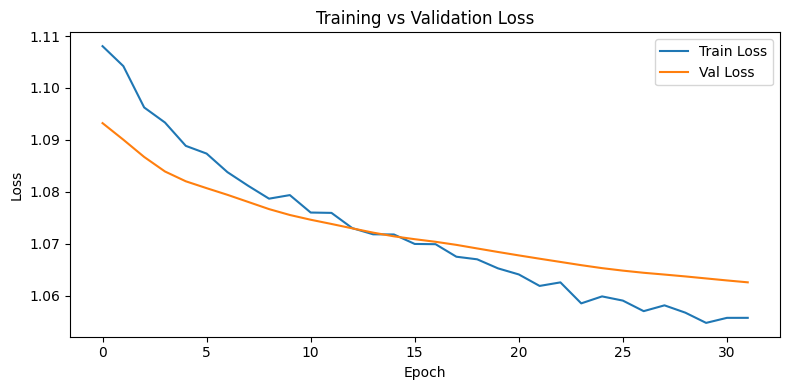

In [31]:
plt.figure(figsize=(8, 4))
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses,   label="Val Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.tight_layout()
plt.show()